#Team 14 End-To-End Pipeline Project (Track B)

This is our notebook containing our work for this project. This contains all the code we have done for the project done in Python script.

Importing Libraries

In [2]:
pip install fredapi wbgapi pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Testing that everything works

In [1]:
from fredapi import Fred
import wbgapi
import pandas as pd

fred = Fred(api_key='59f083159c51d8c8bc51ac462c61a1f9')
print("Environment is Ready!")

Environment is Ready!


**Cell 1: Imports**

In [2]:
from fredapi import Fred
import wbgapi as wb
import pandas as pd

**Cell 2: Connect to Fred**

In [3]:
fred = Fred(api_key='a9713eaadd48f6245b56b5828e93669a')

**Cell 3: Pull GDP Data**

In [4]:
gdp = fred.get_series('GDPC1', observation_start='2000-01-01', observation_end='2023-12-31')
gdp_df = gdp.reset_index()
gdp_df.columns = ['date', 'gdp']
gdp_df.head()

,date,gdp
0,2000-01-01,13878.147
1,2000-04-01,14130.908
2,2000-07-01,14145.312
3,2000-10-01,14229.765
4,2001-01-01,14183.120


**Cell 4: Pull CPI Data**

In [5]:
cpi = fred.get_series('CPIAUCSL', observation_start='2000-01-01', observation_end='2023-12-31')
cpi_df = cpi.reset_index()
cpi_df.columns = ['date', 'cpi']
cpi_df.head()

,date,cpi
0,2000-01-01,169.3
1,2000-02-01,170.0
2,2000-03-01,171.0
3,2000-04-01,170.9
4,2000-05-01,171.2


**Cell 5: Pull Trade Balance Data**

In [6]:
trade_balance = fred.get_series('BOPGTB', observation_start='2000-01-01', observation_end='2023-12-31')
trade_df = trade_balance.reset_index()
trade_df.columns = ['date', 'trade_balance']
trade_df.head()

,date,trade_balance
0,2000-01-01,-33360.0
1,2000-02-01,-36214.0
2,2000-03-01,-37326.0
3,2000-04-01,-35671.0
4,2000-05-01,-35883.0


**Cell 6: Pull World Bank Data**

In [7]:
trade_wb = wb.data.DataFrame('NE.TRD.GNFS.ZS', 'USA', mrv=23)
trade_wb.head()

,YR2002,YR2003,YR2004,YR2005,YR2006,YR2007,YR2008,YR2009,YR2010,YR2011,...,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023,YR2024
economy,,,,,,,,,,,,,,,,,,,,,
USA,22.286374,22.627313,24.448062,25.638553,26.975278,28.012018,29.867796,24.759531,28.219895,30.842486,...,27.823565,26.607962,27.313021,27.610379,26.453759,23.401563,25.609558,27.31394,25.29033,25.378634


**Cell 7: Save to CSV**

In [8]:
gdp_df.to_csv('gdp_data.csv', index=False)
cpi_df.to_csv('cpi_data.csv', index=False)
trade_df.to_csv('trade_balance_data.csv', index=False)
trade_wb.to_csv('world_bank_trade.csv')
print("All files saved!")

All files saved!


---
## Data Cleaning & Merging
The cells below clean each dataset, standardize them to an annual frequency, and merge them into a single analysis-ready DataFrame.

**Cell 8: Clean CPI Data (Monthly → Annual)**

In [9]:
# Parse dates and extract year
cpi_df['date'] = pd.to_datetime(cpi_df['date'])
cpi_df['year'] = cpi_df['date'].dt.year

# Drop any nulls
cpi_df = cpi_df.dropna(subset=['cpi'])

# Aggregate to annual average CPI
cpi_annual = (
    cpi_df.groupby('year')['cpi']
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={'cpi': 'cpi_avg'})
)

# Year-over-year inflation rate (%)
cpi_annual['inflation_rate_pct'] = (cpi_annual['cpi_avg'].pct_change() * 100).round(3)

print(f"CPI cleaned: {cpi_annual['year'].min()}–{cpi_annual['year'].max()} ({len(cpi_annual)} rows)")
cpi_annual.head()

CPI cleaned: 2000–2023 (24 rows)


,year,cpi_avg,inflation_rate_pct
0,2000,172.192,NaN
1,2001,177.042,2.817
2,2002,179.867,1.596
3,2003,184.000,2.298
4,2004,188.908,2.667


**Cell 9: Clean GDP Data (Quarterly → Annual)**

In [10]:
# Parse dates and extract year
gdp_df['date'] = pd.to_datetime(gdp_df['date'])
gdp_df['year'] = gdp_df['date'].dt.year

# Drop any nulls
gdp_df = gdp_df.dropna(subset=['gdp'])

# Aggregate to annual average GDP (average of 4 quarters)
gdp_annual = (
    gdp_df.groupby('year')['gdp']
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={'gdp': 'gdp_avg_billions'})
)

# Year-over-year GDP growth rate (%)
gdp_annual['gdp_growth_rate_pct'] = (gdp_annual['gdp_avg_billions'].pct_change() * 100).round(3)

print(f"GDP cleaned: {gdp_annual['year'].min()}–{gdp_annual['year'].max()} ({len(gdp_annual)} rows)")
gdp_annual.head()

GDP cleaned: 2000–2023 (24 rows)


,year,gdp_avg_billions,gdp_growth_rate_pct
0,2000,14096.033,NaN
1,2001,14230.726,0.956
2,2002,14472.712,1.700
3,2003,14877.312,2.796
4,2004,15449.757,3.848


**Cell 10: Clean Trade Balance Data (Monthly → Annual)**

In [11]:
# Parse dates and extract year
trade_df['date'] = pd.to_datetime(trade_df['date'])
trade_df['year'] = trade_df['date'].dt.year

# Drop any nulls
trade_df = trade_df.dropna(subset=['trade_balance'])

# Aggregate to annual average monthly trade balance (millions USD)
trade_annual = (
    trade_df.groupby('year')['trade_balance']
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={'trade_balance': 'trade_balance_avg_millions'})
)

print(f"Trade Balance cleaned: {trade_annual['year'].min()}–{trade_annual['year'].max()} ({len(trade_annual)} rows)")
trade_annual.head()

Trade Balance cleaned: 2000–2023 (24 rows)


,year,trade_balance_avg_millions
0,2000,-37231.750
1,2001,-35197.500
2,2002,-39603.667
3,2003,-45136.917
4,2004,-55397.167


**Cell 11: Clean World Bank Data (Wide → Long Format)**

In [12]:
# Reload the World Bank CSV to ensure clean state
wb_df = pd.read_csv('world_bank_trade.csv')
wb_df.columns = wb_df.columns.str.strip().str.lower()

# Melt from wide format (one column per year) to long format
wb_melted = wb_df.melt(
    id_vars=['economy'],
    var_name='year_str',
    value_name='trade_pct_gdp'
)

# Extract numeric year from strings like 'yr2002'
wb_melted['year'] = wb_melted['year_str'].str.extract(r'(\d{4})').astype(int)
wb_melted['trade_pct_gdp'] = wb_melted['trade_pct_gdp'].round(3)

# Keep only needed columns, drop nulls, sort
wb_annual = (
    wb_melted[['year', 'trade_pct_gdp']]
    .dropna(subset=['trade_pct_gdp'])
    .sort_values('year')
    .reset_index(drop=True)
)

print(f"World Bank cleaned: {wb_annual['year'].min()}–{wb_annual['year'].max()} ({len(wb_annual)} rows)")
wb_annual.head()

World Bank cleaned: 2002–2024 (23 rows)


,year,trade_pct_gdp
0,2002,22.286
1,2003,22.627
2,2004,24.448
3,2005,25.639
4,2006,26.975


**Cell 12: Merge All Datasets on Year**

In [13]:
# Inner join all four datasets on year
merged_df = cpi_annual.merge(gdp_annual,    on='year', how='inner')
merged_df = merged_df.merge(trade_annual,   on='year', how='inner')
merged_df = merged_df.merge(wb_annual,      on='year', how='inner')

# Filter to project scope: 2000–2023
merged_df = merged_df[(merged_df['year'] >= 2000) & (merged_df['year'] <= 2023)]
merged_df = merged_df.sort_values('year').reset_index(drop=True)

print(f"Merged dataset shape: {merged_df.shape}")
print(f"Years covered: {merged_df['year'].min()}–{merged_df['year'].max()}")
print(f"Columns: {list(merged_df.columns)}")
merged_df.head()

Merged dataset shape: (22, 7)
Years covered: 2002–2023
Columns: ['year', 'cpi_avg', 'inflation_rate_pct', 'gdp_avg_billions', 'gdp_growth_rate_pct', 'trade_balance_avg_millions', 'trade_pct_gdp']


,year,cpi_avg,inflation_rate_pct,gdp_avg_billions,gdp_growth_rate_pct,trade_balance_avg_millions,trade_pct_gdp
0,2002,179.867,1.596,14472.712,1.700,-39603.667,22.286
1,2003,184.000,2.298,14877.312,2.796,-45136.917,22.627
2,2004,188.908,2.667,15449.757,3.848,-55397.167,24.448
3,2005,195.267,3.366,15987.958,3.484,-65233.500,25.639
4,2006,201.558,3.222,16433.148,2.785,-69774.000,26.975


**Cell 13: Validate Merged Data**

In [14]:
# Check for any remaining nulls
print("── Null Check ──────────────────────────────")
print(merged_df.isnull().sum())

── Null Check ──────────────────────────────
year                          0
cpi_avg                       0
inflation_rate_pct            0
gdp_avg_billions              0
gdp_growth_rate_pct           0
trade_balance_avg_millions    0
trade_pct_gdp                 0
dtype: int64


**Cell 14: Save Merged Dataset to CSV**

In [15]:
merged_df.to_csv('merged_macro_data.csv', index=False)
print("Merged dataset saved to: merged_macro_data.csv")
print(f"Final shape: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}")

Merged dataset saved to: merged_macro_data.csv
Final shape: (22, 7)
Columns: ['year', 'cpi_avg', 'inflation_rate_pct', 'gdp_avg_billions', 'gdp_growth_rate_pct', 'trade_balance_avg_millions', 'trade_pct_gdp']


---
## Analysis: Correlation, Time-Series, Regression & Statistical Tests
The cells below implement the full analysis pipeline on the merged dataset.

**Cell 15: Import Analysis Libraries**

In [15]:
pip install scipy scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 265.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 179.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Analysis libraries loaded.")

Analysis libraries loaded.


**Cell 16: Correlation Analysis — Trade Balance vs All Variables**

In [17]:
corr_cols = [
    'trade_balance_avg_millions',
    'gdp_avg_billions',
    'gdp_growth_rate_pct',
    'cpi_avg',
    'inflation_rate_pct',
    'trade_pct_gdp'
]

corr_matrix = merged_df[corr_cols].corr().round(3)

print("── Pearson Correlation Matrix ──────────────────────────")
print(corr_matrix)

print("\n── Correlations with Trade Balance (sorted) ────────────")
print(corr_matrix['trade_balance_avg_millions'].drop('trade_balance_avg_millions').sort_values())

── Pearson Correlation Matrix ──────────────────────────
                            trade_balance_avg_millions  gdp_avg_billions  \
trade_balance_avg_millions                       1.000            -0.846   
gdp_avg_billions                                -0.846             1.000   
gdp_growth_rate_pct                             -0.312             0.170   
cpi_avg                                         -0.819             0.980   
inflation_rate_pct                              -0.725             0.385   
trade_pct_gdp                                   -0.173             0.102   

                            gdp_growth_rate_pct  cpi_avg  inflation_rate_pct  \
trade_balance_avg_millions               -0.312   -0.819              -0.725   
gdp_avg_billions                          0.170    0.980               0.385   
gdp_growth_rate_pct                       1.000    0.097               0.411   
cpi_avg                                   0.097    1.000               0.399   
inflation_

**Cell 17: Time-Series Analysis — Year-over-Year Percentage Changes**

In [18]:
pct_change_cols = ['trade_balance_avg_millions', 'gdp_avg_billions', 'cpi_avg', 'trade_pct_gdp']
pct_df = merged_df[['year'] + pct_change_cols].copy()

for col in pct_change_cols:
    pct_df[f'{col}_pct_chg'] = pct_df[col].pct_change().mul(100).round(3)

print("── Year-over-Year Percentage Changes ───────────────────")
display_cols = ['year'] + [f'{c}_pct_chg' for c in pct_change_cols]
print(pct_df[display_cols].to_string(index=False))

print("\n── Summary Statistics of Annual % Changes ──────────────")
print(pct_df[[f'{c}_pct_chg' for c in pct_change_cols]].describe().round(3))

── Year-over-Year Percentage Changes ───────────────────
 year  trade_balance_avg_millions_pct_chg  gdp_avg_billions_pct_chg  cpi_avg_pct_chg  trade_pct_gdp_pct_chg
 2002                                 NaN                       NaN              NaN                    NaN
 2003                              13.972                     2.796            2.298                  1.530
 2004                              22.731                     3.848            2.667                  8.048
 2005                              17.756                     3.484            3.366                  4.872
 2006                               6.960                     2.785            3.222                  5.211
 2007                              -1.922                     2.004            2.871                  3.844
 2008                               1.376                     0.114            3.815                  6.626
 2009                             -38.775                    -2.577           -

**Cell 18: Simple Linear Regression — Trade Balance vs Key Variables**

In [19]:
reg_df = merged_df.dropna(subset=['gdp_growth_rate_pct', 'inflation_rate_pct']).copy()

targets = [
    ('gdp_avg_billions',    'GDP (Billions USD)'),
    ('gdp_growth_rate_pct', 'GDP Growth Rate (%)'),
    ('inflation_rate_pct',  'Inflation Rate (%)'),
    ('trade_pct_gdp',       'Trade as % of GDP'),
]

print("── Regression Results: Trade Balance → Each Variable ───")

for target_col, target_label in targets:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        reg_df['trade_balance_avg_millions'], reg_df[target_col]
    )
    r2 = r_value ** 2

    print(f"\nTrade Balance → {target_label}")
    print(f"  Coefficient : {slope:.5f}")
    print(f"  Intercept   : {intercept:.3f}")
    print(f"  R²          : {r2:.4f}")
    print(f"  p-value     : {p_value:.4f} {'*** significant' if p_value < 0.05 else '(not significant)'}")

── Regression Results: Trade Balance → Each Variable ───

Trade Balance → GDP (Billions USD)
  Coefficient : -0.13816
  Intercept   : 9096.549
  R²          : 0.7165
  p-value     : 0.0000 *** significant

Trade Balance → GDP Growth Rate (%)
  Coefficient : -0.00004
  Intercept   : -0.409
  R²          : 0.0971
  p-value     : 0.1581 (not significant)

Trade Balance → Inflation Rate (%)
  Coefficient : -0.00009
  Intercept   : -3.157
  R²          : 0.5261
  p-value     : 0.0001 *** significant

Trade Balance → Trade as % of GDP
  Coefficient : -0.00003
  Intercept   : 24.937
  R²          : 0.0298
  p-value     : 0.4420 (not significant)


**Cell 19: ANOVA Test — Trade Deficit Across Time Periods**

In [20]:
def assign_period(year):
    if year < 2010:
        return '2002-2009'
    elif year < 2020:
        return '2010-2019'
    else:
        return '2020-2023'

merged_df['period'] = merged_df['year'].apply(assign_period)

groups = [
    merged_df.loc[merged_df['period'] == p, 'trade_balance_avg_millions'].values
    for p in ['2002-2009', '2010-2019', '2020-2023']
]

f_stat, p_value = stats.f_oneway(*groups)

print("── One-Way ANOVA: Trade Balance by Period ──────────────")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
if p_value < 0.05:
    print("  Result      : Statistically significant difference across periods (p < 0.05)")
else:
    print("  Result      : No statistically significant difference across periods (p >= 0.05)")

print("\n── Mean Trade Balance by Period ────────────────────────")
period_summary = (
    merged_df.groupby('period')['trade_balance_avg_millions']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .round(2)
    .reindex(['2002-2009', '2010-2019', '2020-2023'])
)
period_summary.columns = ['Mean', 'Std Dev', 'Min', 'Max', 'N']
print(period_summary)

── One-Way ANOVA: Trade Balance by Period ──────────────
  F-statistic : 14.8285
  p-value     : 0.0001
  Result      : Statistically significant difference across periods (p < 0.05)

── Mean Trade Balance by Period ────────────────────────
               Mean   Std Dev       Min       Max   N
period                                               
2002-2009 -56928.39  12937.69 -69774.00 -39603.67   8
2010-2019 -63568.92   5684.94 -73228.92 -54055.92  10
2020-2023 -88085.98   9036.93 -97880.42 -76072.92   4


**Cell 20: Summary Statistics — Comparing Means Across Periods**

In [21]:
summary_cols = [
    'trade_balance_avg_millions',
    'gdp_avg_billions',
    'gdp_growth_rate_pct',
    'cpi_avg',
    'inflation_rate_pct',
    'trade_pct_gdp'
]

print("── Mean Values by Period ───────────────────────────────")
period_means = (
    merged_df.groupby('period')[summary_cols]
    .mean()
    .round(3)
    .reindex(['2002-2009', '2010-2019', '2020-2023'])
)
print(period_means.T.to_string())

print("\n── Overall Descriptive Statistics (2002–2023) ──────────")
print(merged_df[summary_cols].describe().round(3))

── Mean Values by Period ───────────────────────────────
period                      2002-2009  2010-2019  2020-2023
trade_balance_avg_millions -56928.386 -63568.917 -88085.980
gdp_avg_billions            15889.241  18582.176  21654.139
gdp_growth_rate_pct             1.769      2.396      2.382
cpi_avg                       198.345    237.113    281.790
inflation_rate_pct              2.439      1.770      4.513
trade_pct_gdp                  25.577     28.556     25.404

── Overall Descriptive Statistics (2002–2023) ──────────
       trade_balance_avg_millions  gdp_avg_billions  gdp_growth_rate_pct  \
count                      22.000            22.000               22.000   
mean                   -65611.826         18161.466                2.166   
std                     14430.216          2355.323                1.817   
min                    -97880.417         14472.712               -2.577   
25%                    -71022.313         16515.472                1.865   
50%      

---
## Visualizations
The cells below include visualizations that represent the reuslts of the correlation analysis tests.

In [ ]:
# Ensure matplotlib is installed
pip install matplotlib

In [22]:
import matplotlib.pyplot as p

print("Visualization libraries loaded.")

Visualization libraries loaded.


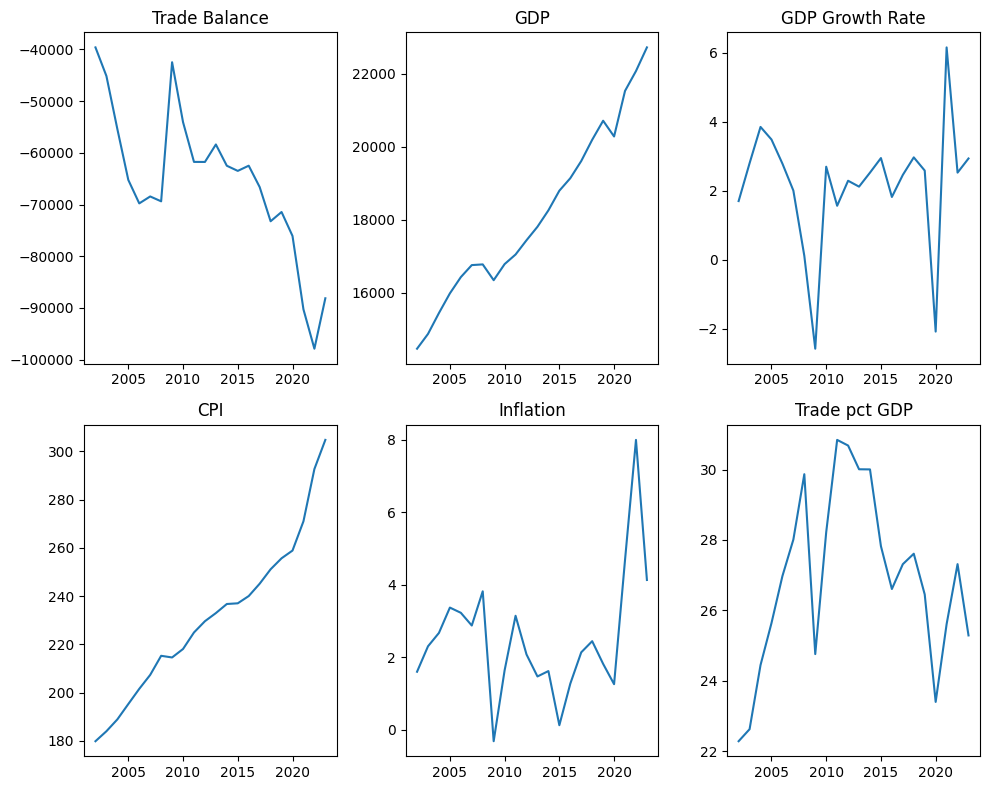

In [91]:
# Visualization of the variables over the years
fig, axes = p.subplots(2, 3, figsize=(10, 8))

axes[0, 0].plot(merged_df['year'], merged_df["trade_balance_avg_millions"])
axes[0, 0].set_title("Trade Balance")

axes[0, 1].plot(merged_df['year'], merged_df["gdp_avg_billions"])
axes[0, 1].set_title("GDP")

axes[1, 0].plot(merged_df['year'], merged_df["cpi_avg"])
axes[1, 0].set_title("CPI")

axes[1, 1].plot(merged_df['year'], merged_df["inflation_rate_pct"])
axes[1, 1].set_title("Inflation")

axes[0,2].plot(merged_df['year'], merged_df["gdp_growth_rate_pct"])
axes[0,2].set_title("GDP Growth Rate")

axes[1,2].plot(merged_df['year'], merged_df["trade_pct_gdp"])
axes[1,2].set_title("Trade pct GDP")
p.tight_layout()
p.show()

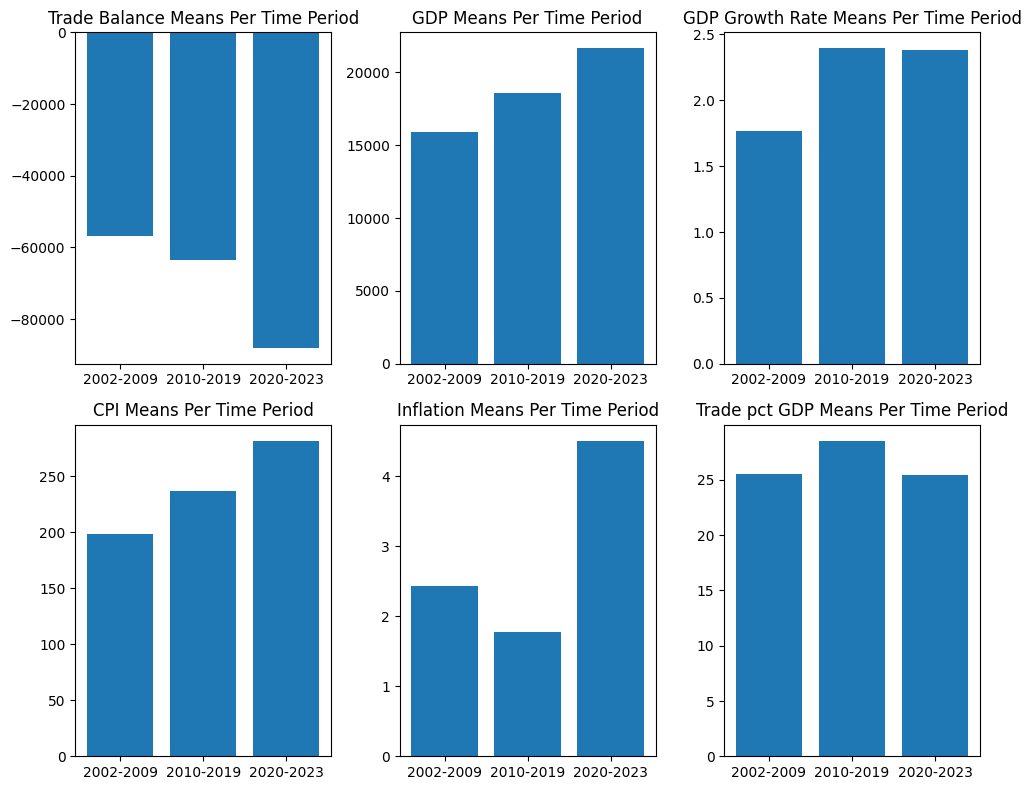

In [90]:
# Visualizing the means over the designated time periods


fig, axes = p.subplots(2, 3, figsize=(10, 8))

axes[0, 0].bar(period_means.index, period_means["trade_balance_avg_millions"])
axes[0, 0].set_title("Trade Balance Means Per Time Period")

axes[0, 1].bar(period_means.index, period_means["gdp_avg_billions"])
axes[0, 1].set_title("GDP Means Per Time Period")

axes[1, 0].bar(period_means.index, period_means["cpi_avg"])
axes[1, 0].set_title("CPI Means Per Time Period")

axes[1, 1].bar(period_means.index, period_means["inflation_rate_pct"])
axes[1, 1].set_title("Inflation Means Per Time Period")

axes[0,2].bar(period_means.index, period_means["gdp_growth_rate_pct"])
axes[0,2].set_title("GDP Growth Rate Means Per Time Period")

axes[1,2].bar(period_means.index, period_means["trade_pct_gdp"])
axes[1,2].set_title("Trade pct GDP Means Per Time Period")
p.tight_layout()
p.show()

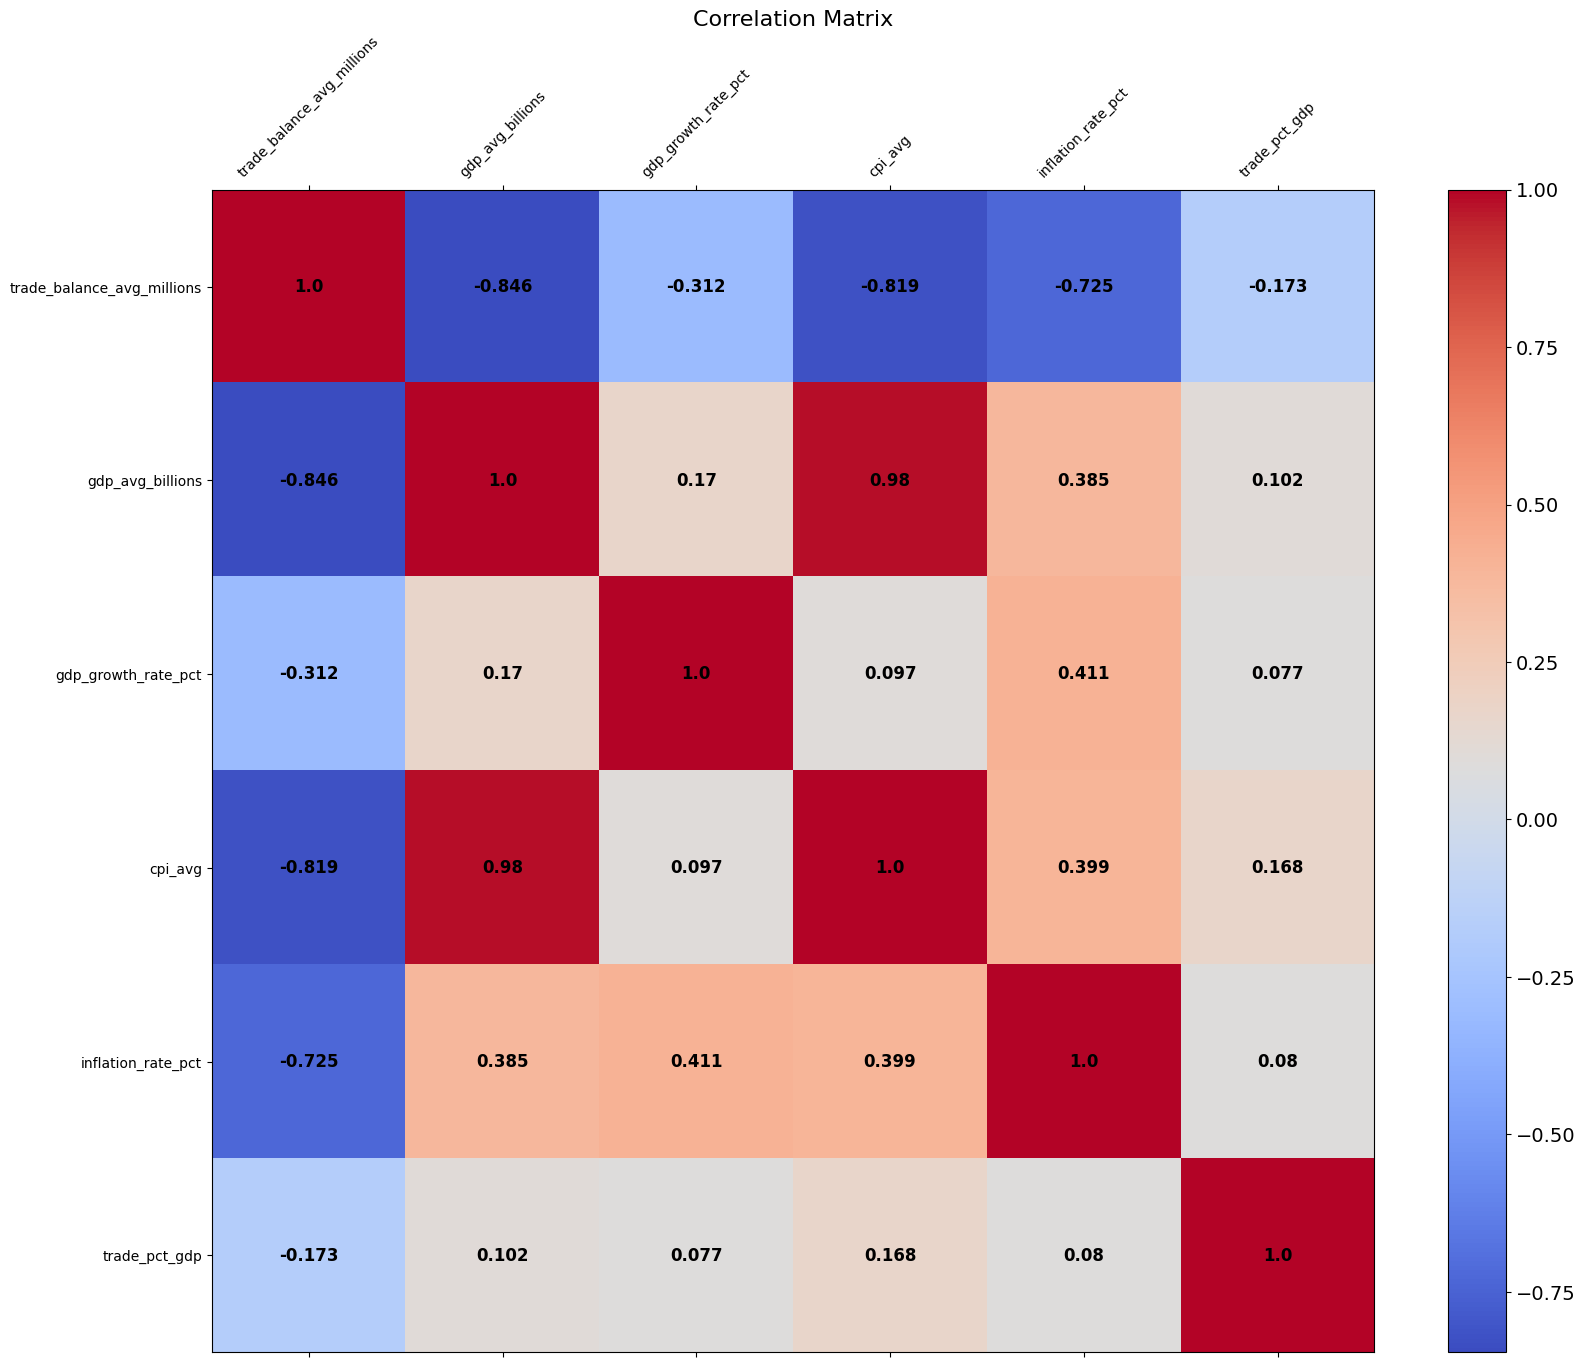

In [65]:
#Visualizing the corrolations

f = p.figure(figsize=(19, 15))
p.matshow(corr_matrix, fignum=f.number, cmap = 'coolwarm')
cb = p.colorbar()
cb.ax.tick_params(labelsize=14)
p.title('Correlation Matrix', fontsize=16)

p.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
p.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for x in range(len(corr_matrix.columns)):
    for y in range(len(corr_matrix.columns)):
        p.text(y, x, f"{corr_matrix.iloc[x, y]}",
               ha='center', va='center', color='black', fontweight='bold', fontsize = 12)

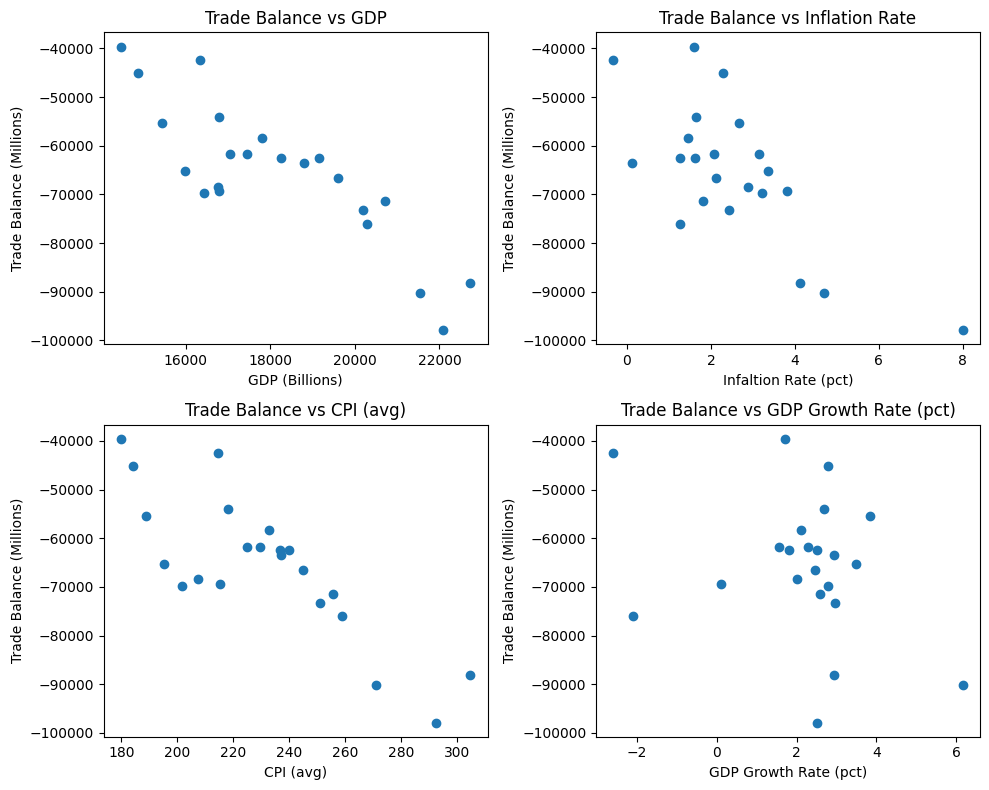

In [92]:
#Scatter plots for the strongest corrolations for trade_balance_avg_millions

fig, axes = p.subplots(2, 2, figsize=(10, 8))

axes[0,0].scatter(merged_df["gdp_avg_billions"], merged_df["trade_balance_avg_millions"])
axes[0,0].set_title("Trade Balance vs GDP")
axes[0,0].set_xlabel("GDP (Billions)")
axes[0,0].set_ylabel("Trade Balance (Millions)")

axes[0,1].scatter(merged_df['inflation_rate_pct'], merged_df["trade_balance_avg_millions"])
axes[0,1].set_title("Trade Balance vs Inflation Rate")
axes[0,1].set_xlabel("Infaltion Rate (pct)")
axes[0,1].set_ylabel("Trade Balance (Millions)")

axes[1,0].scatter(merged_df['cpi_avg'], merged_df["trade_balance_avg_millions"])
axes[1,0].set_title("Trade Balance vs CPI (avg)")
axes[1,0].set_xlabel("CPI (avg)")
axes[1,0].set_ylabel("Trade Balance (Millions)")

axes[1, 1].scatter(merged_df['gdp_growth_rate_pct'], merged_df["trade_balance_avg_millions"])
axes[1, 1].set_title("Trade Balance vs GDP Growth Rate (pct)")
axes[1,1].set_xlabel("GDP Growth Rate (pct)")
axes[1,1].set_ylabel("Trade Balance (Millions)")


p.tight_layout()
p.show()
